# experiments, pop_baseline vs als

this notebook compares three offline baselines for cart-oriented recs:

- popularity
- als
- co-visitation

In [1]:
import os
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from implicit.als import AlternatingLeastSquares

os.environ.pop("MPLBACKEND", None)

current_dir = Path.cwd().resolve()
candidate_roots = [current_dir, *current_dir.parents]
project_root = next(path for path in candidate_roots
    if (path / "src").exists() and (path / "params.yaml").exists()
)

src_dir = project_root / "src"

if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from cart_driven_recsys.config import cfg
from cart_driven_recsys.covisit import build_covisit_index
from cart_driven_recsys.recommenders import (
    build_item_popularity_ranking,
    evaluate_recommender,
    recommend_with_als,
    recommend_with_covisit,
    recommend_with_popularity,
    sample_sessions,
)
from cart_driven_recsys.train import (
    build_interaction_matrix,
    load_raw_addtocart_events,
    load_weighted_events,
    split_by_time,
    train_als_model,
)

als_params = cfg.params["als"]
eval_params = cfg.params["eval"]
covisit_params = cfg.params["covisit"]

evaluation_k = eval_params["k"]
random_seed = 42

/home/mle-user/mle_projects/cart-driven-recsys/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
weighted_events_dataframe = load_weighted_events()

print(f"weighted events: {len(weighted_events_dataframe):,}")
print(f"users: {weighted_events_dataframe['user_id'].nunique():,}")
print(f"items: {weighted_events_dataframe['item_id'].nunique():,}")
print(
    f"event time range: "
    f"{weighted_events_dataframe['event_time'].min()} -> "
    f"{weighted_events_dataframe['event_time'].max()}"
)

weighted_events_dataframe.head()

weighted events: 2,756,101
users: 1,407,580
items: 235,061
event time range: 2015-05-03 03:00:04.384000+00:00 -> 2015-09-18 02:59:47.788000+00:00


,user_id,item_id,event_time,weight
0,241793,287090,2015-05-03 05:45:20.036000+00:00,1.0
1,1206788,116444,2015-05-03 05:24:11.248000+00:00,1.0
2,624610,362372,2015-05-03 05:26:57.282000+00:00,1.0
3,1407102,454806,2015-05-03 05:20:50.987000+00:00,1.0
4,283409,262826,2015-05-03 05:17:00.903000+00:00,1.0


In [4]:
train_interactions_dataframe, test_events_dataframe, cutoff_timestamp = split_by_time(weighted_events_dataframe, eval_params["test_days"])

interaction_matrix, item_ids = build_interaction_matrix(train_interactions_dataframe)
item_popularity_ranking = build_item_popularity_ranking(train_interactions_dataframe)

raw_addtocart_events_dataframe = load_raw_addtocart_events()
train_addtocart_events_dataframe = raw_addtocart_events_dataframe[raw_addtocart_events_dataframe["event_time"] < cutoff_timestamp].copy()

sampled_sessions = sample_sessions(
    test_events_dataframe,
    eval_params["session_gap_hours"],
    eval_params["n_sessions"],
    random_seed,
)

matrix_density = interaction_matrix.nnz / (interaction_matrix.shape[0] * interaction_matrix.shape[1])

In [ ]:
print(f"train interactions: {len(train_interactions_dataframe):,}")
print(f"train events: {len(train_addtocart_events_dataframe):,}")
print(f"test events: {len(test_events_dataframe):,}")
print(f"sampled sessions: {len(sampled_sessions):,}")
print(f"matrix shape: "f"{interaction_matrix.shape[0]:,} x {interaction_matrix.shape[1]:,}")
print(f"non-zero entries: {interaction_matrix.nnz:,}")
print(f"density: {matrix_density:.6%}")
print(f"top-10 popular items: {item_popularity_ranking[:10]}")

cutoff date: 2015-08-19
train interactions: 1,727,867
train events: 55,482
test events: 13,850
sampled sessions: 1,992
matrix shape: 1,133,422 x 213,717
non-zero entries: 1,727,867
density: 0.000713%
top-10 popular items: [461686, 257040, 5411, 7943, 309778, 187946, 48030, 312728, 369447, 29196]


In [6]:
def print_metrics(title: str, metrics: dict[str, float | int]):
    print(title)
    for metric_name, metric_value in metrics.items():
        if isinstance(metric_value, float):
            print(f"{metric_name}: {metric_value:.4f}")
        else:
            print(f"{metric_name}: {metric_value}")
    print()

In [7]:
popularity_metrics = evaluate_recommender(
    lambda cart_item_ids, k: recommend_with_popularity(item_popularity_ranking, cart_item_ids, k),
    sampled_sessions,
    item_ids,
    item_popularity_ranking,
    evaluation_k,
)

print_metrics("popularity baseline metrics:", popularity_metrics)

popularity baseline metrics:
hit@10: 0.0050
ndcg@10: 0.0044
coverage@10: 0.0001
popularity_bias_top_1pct: 1.0000
n_sessions: 1992



In [8]:
als_model = train_als_model(interaction_matrix)
item_id_to_index = {int(item_id): item_index for item_index, item_id in enumerate(item_ids)}

als_metrics = evaluate_recommender(
    lambda cart_item_ids, k: recommend_with_als(als_model, item_ids, item_id_to_index, cart_item_ids, k),
    sampled_sessions,
    item_ids,
    item_popularity_ranking,
    evaluation_k,
)

print_metrics("als metrics:", als_metrics)

/home/mle-user/mle_projects/cart-driven-recsys/.venv/lib/python3.12/site-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 4 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()
100%|██████████| 30/30 [06:29<00:00, 12.98s/it, loss=0.00025] 


als metrics:
hit@10: 0.0562
ndcg@10: 0.0333
coverage@10: 0.0105
popularity_bias_top_1pct: 0.2949
n_sessions: 1992



In [10]:
covisit_index = build_covisit_index(train_addtocart_events_dataframe, eval_params["session_gap_hours"], covisit_params["top_neighbors"])
print(f"covisit source items: {len(covisit_index):,}")

covisit_metrics = evaluate_recommender(
    lambda cart_item_ids, k: recommend_with_covisit(covisit_index, cart_item_ids, k),
    sampled_sessions,
    item_ids,
    item_popularity_ranking,
    evaluation_k,
)

print_metrics("co-visitation metrics:", covisit_metrics)

covisit source items: 13,310
co-visitation metrics:
hit@10: 0.0447
ndcg@10: 0.0308
coverage@10: 0.0221
popularity_bias_top_1pct: 0.3384
n_sessions: 1992



In [11]:
comparison_dataframe = pd.DataFrame(
    [
        {"model": "popularity", **popularity_metrics},
        {"model": "als", **als_metrics},
        {"model": "co_visitation", **covisit_metrics},
    ]
).set_index("model")

comparison_dataframe

,hit@10,ndcg@10,coverage@10,popularity_bias_top_1pct,n_sessions
model,,,,,
popularity,0.005020,0.004391,0.000051,1.000000,1992
als,0.056225,0.033311,0.010533,0.294909,1992
co_visitation,0.044679,0.030822,0.022146,0.338366,1992


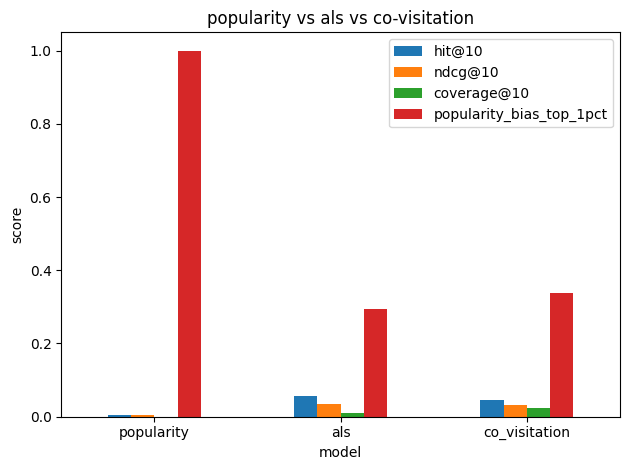

In [12]:
score_columns = [
    f"hit@{evaluation_k}", f"ndcg@{evaluation_k}",
    f"coverage@{evaluation_k}", "popularity_bias_top_1pct",
]

comparison_dataframe[score_columns].plot(kind="bar", rot=0)
plt.title("popularity vs als vs co-visitation")
plt.ylabel("score")
plt.tight_layout()
plt.show()

In [13]:
factor_results: list[dict[str, float | int]] = []

for factor_count in [16, 32, 64, 128]:
    candidate_model = AlternatingLeastSquares(
        factors=factor_count,
        iterations=als_params["iterations"],
        regularization=als_params["regularization"],
        alpha=als_params["alpha"],
        use_gpu=False,
        calculate_training_loss=True,
        random_state=42,
    )
    candidate_model.fit(interaction_matrix)

    candidate_item_id_to_index = {int(item_id): item_index for item_index, item_id in enumerate(item_ids)}

    candidate_metrics = evaluate_recommender(
        lambda cart_item_ids, k, model=candidate_model, item_id_to_index=candidate_item_id_to_index: recommend_with_als(
            model, item_ids, item_id_to_index, cart_item_ids, k
        ),
        sampled_sessions,
        item_ids,
        item_popularity_ranking,
        evaluation_k,
    )

    factor_results.append({"factors": factor_count, **candidate_metrics})

factor_results_dataframe = pd.DataFrame(factor_results).set_index("factors")
factor_results_dataframe

  0%|          | 0/30 [00:00<?, ?it/s]

100%|██████████| 30/30 [06:25<00:00, 12.85s/it, loss=0.00025] 


,hit@10,ndcg@10,coverage@10,popularity_bias_top_1pct,n_sessions
factors,,,,,
16,0.033635,0.018867,0.003762,0.993299,1992
32,0.048193,0.027007,0.006321,0.973610,1992
64,0.060241,0.035275,0.010724,0.850597,1992
128,0.056225,0.033311,0.010533,0.294909,1992


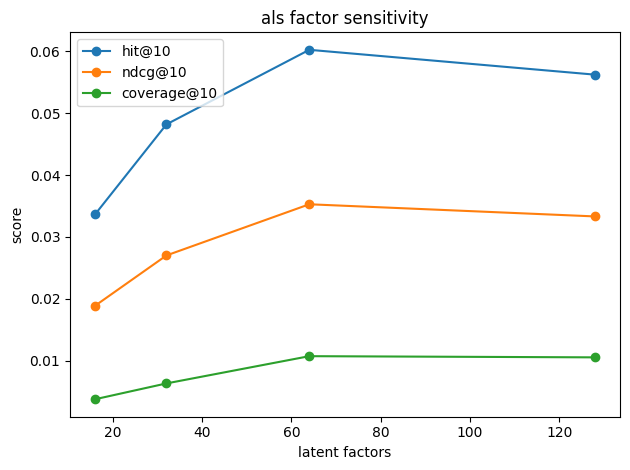

In [14]:
factor_results_dataframe[[f"hit@{evaluation_k}", f"ndcg@{evaluation_k}", f"coverage@{evaluation_k}"]].plot(marker="o")
plt.title("als factor sensitivity")
plt.xlabel("latent factors")
plt.ylabel("score")
plt.tight_layout()
plt.show()

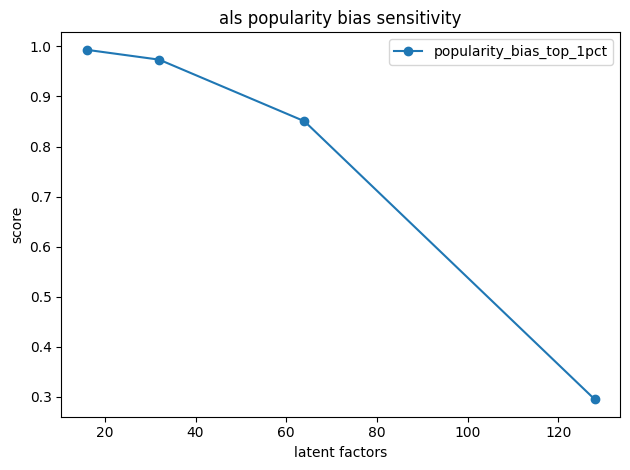

In [15]:
factor_results_dataframe[["popularity_bias_top_1pct"]].plot(marker="o")
plt.title("als popularity bias sensitivity")
plt.xlabel("latent factors")
plt.ylabel("score")
plt.tight_layout()
plt.show()

In [17]:
covisit_results: list[dict[str, float | int]] = []

for top_neighbors_per_item in [50, 100, 200, 400]:
    candidate_covisit_index = build_covisit_index(
        train_addtocart_events_dataframe,
        eval_params["session_gap_hours"],
        top_neighbors_per_item,
    )

    candidate_metrics = evaluate_recommender(
        lambda cart_item_ids, k, covisit_index=candidate_covisit_index: recommend_with_covisit(
            covisit_index, cart_item_ids, k
        ),
        sampled_sessions,
        item_ids,
        item_popularity_ranking,
        evaluation_k,
    )

    covisit_results.append({"top_neighbors_per_item": top_neighbors_per_item, **candidate_metrics})

covisit_results_dataframe = pd.DataFrame(covisit_results).set_index("top_neighbors_per_item")
covisit_results_dataframe

,hit@10,ndcg@10,coverage@10,popularity_bias_top_1pct,n_sessions
top_neighbors_per_item,,,,,
50,0.044679,0.030822,0.022146,0.338366,1992
100,0.044679,0.030822,0.022151,0.338466,1992
200,0.044679,0.030822,0.022151,0.338566,1992
400,0.044679,0.030822,0.022151,0.338566,1992


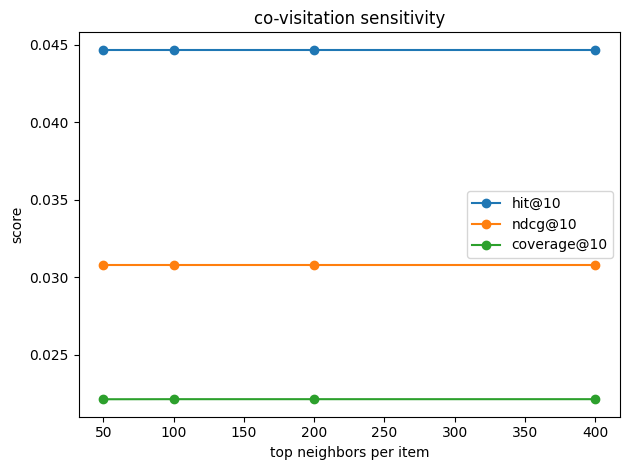

In [18]:
covisit_results_dataframe[[f"hit@{evaluation_k}", f"ndcg@{evaluation_k}", f"coverage@{evaluation_k}"]].plot(marker="o")
plt.title("co-visitation sensitivity")
plt.xlabel("top neighbors per item")
plt.ylabel("score")
plt.tight_layout()
plt.show()

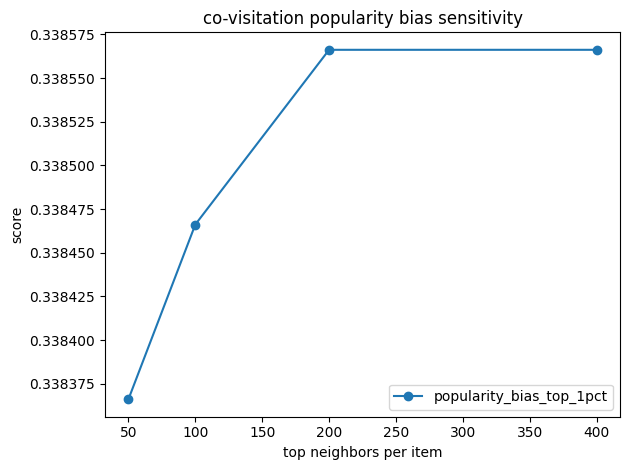

In [19]:
covisit_results_dataframe[["popularity_bias_top_1pct"]].plot(marker="o")
plt.title("co-visitation popularity bias sensitivity")
plt.xlabel("top neighbors per item")
plt.ylabel("score")
plt.tight_layout()
plt.show()

In [20]:
best_als_hit = factor_results_dataframe[f"hit@{evaluation_k}"].idxmax()
best_als_ndcg = factor_results_dataframe[f"ndcg@{evaluation_k}"].idxmax()
best_covisit_hit = covisit_results_dataframe[f"hit@{evaluation_k}"].idxmax()
best_covisit_ndcg = covisit_results_dataframe[f"ndcg@{evaluation_k}"].idxmax()

In [23]:
summary_rows = []

summary_rows.append({"criterion": f"best als hit@{evaluation_k}", "value": int(best_als_hit)})
summary_rows.append({"criterion": f"best als ndcg@{evaluation_k}", "value": int(best_als_ndcg)})
summary_rows.append({"criterion": f"best covisit hit@{evaluation_k}", "value": int(best_covisit_hit)})
summary_rows.append({"criterion": f"best covisit ndcg@{evaluation_k}", "value": int(best_covisit_ndcg)})

pd.DataFrame(summary_rows)

,criterion,value
0,best als hit@10,64
1,best als ndcg@10,64
2,best covisit hit@10,50
3,best covisit ndcg@10,50


In [24]:
summary_rows.append({"criterion": f"best ALS hit@{evaluation_k}", "value": int(best_als_hit)})
summary_rows.append({"criterion": f"best ALS ndcg@{evaluation_k}", "value": int(best_als_ndcg)})
summary_rows.append({"criterion": f"best covisit hit@{evaluation_k}", "value": int(best_covisit_hit)})
summary_rows.append({"criterion": f"best covisit ndcg@{evaluation_k}", "value": int(best_covisit_ndcg)})
pd.DataFrame(summary_rows)

,criterion,value
0,best als hit@10,64
1,best als ndcg@10,64
2,best covisit hit@10,50
3,best covisit ndcg@10,50
4,best ALS hit@10,64
5,best ALS ndcg@10,64
6,best covisit hit@10,50
7,best covisit ndcg@10,50


ALS gave the best results in the experiment, it had the highest hit@10 and ndcg@10, so it predicts the next cart item better than the other baselines.

Co-visitation was also strong, it was a bit worse than als on ranking quality, but it had much better coverage, which means it recommended a wider range of items.

The pop baseline was the weakest, it mostly recommended only the most popular products and had the highest popularity bias.

For als the best number of latent factors was 64, using more factors did not improve the results. For co-visitation increasing the number of neighbors did not change much, so a smaller value like 50 is enough.
Overall, als is the best standalone model here, while co-visitation is a strong simple baseline and a good candidate for a hybrid model.